In [1]:
!pip install networkx torch scikit-learn matplotlib torch-geometric karateclub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of karateclub to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This e

In [2]:
from google.colab import files
uploaded = files.upload()

Saving karate_edges.csv to karate_edges (1).csv


In [3]:
import pandas as pd
import networkx as nx

df = pd.read_csv("karate_edges.csv")

G = nx.from_pandas_edgelist(df, "source", "target")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 33
Edges: 74


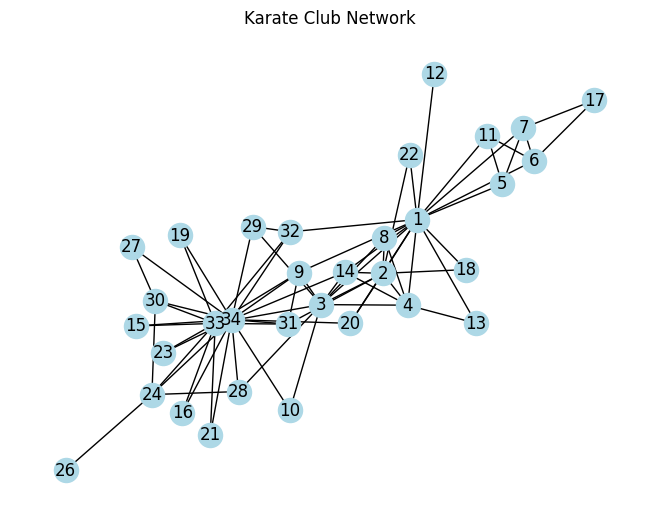

In [4]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)

nx.draw(G, pos, node_color="lightblue", with_labels=True)

plt.title("Karate Club Network")
plt.show()

In [5]:
ground_truth = []

for node in G.nodes():
    if node <= 17:
        ground_truth.append(0)
    else:
        ground_truth.append(1)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

num_nodes = G.number_of_nodes()
embed_dim = 16

class Generator(nn.Module):

    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, embed_dim)

    def forward(self, nodes):
        return self.embedding(nodes)

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(embed_dim,1)

    def forward(self, emb):
        return torch.sigmoid(self.linear(emb))

G_model = Generator()
D_model = Discriminator()

criterion = nn.BCELoss()

g_optimizer = optim.Adam(G_model.parameters(), lr=0.01)
d_optimizer = optim.Adam(D_model.parameters(), lr=0.01)

nodes = torch.arange(num_nodes)

for epoch in range(200):

    real_emb = G_model(nodes)
    real_labels = torch.ones(num_nodes,1)

    fake_emb = torch.randn(num_nodes,embed_dim)
    fake_labels = torch.zeros(num_nodes,1)

    d_loss = criterion(D_model(real_emb), real_labels) + \
             criterion(D_model(fake_emb), fake_labels)

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    gen_emb = G_model(nodes)

    g_loss = criterion(D_model(gen_emb), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

embeddings_gan = G_model.embedding.weight.detach().numpy()

print("CommunityGAN training complete")

CommunityGAN training complete


In [12]:
!pip install torch torch-geometric networkx scikit-learn matplotlib

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.8 MB/s eta 0:00:00


In [13]:
import pandas as pd
import networkx as nx

df = pd.read_csv("karate_edges.csv")

G = nx.from_pandas_edgelist(df, "source", "target")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 33
Edges: 74


In [14]:
import torch
from torch_geometric.utils import from_networkx

data = from_networkx(G)

num_nodes = G.number_of_nodes()

# Node features (identity matrix)
x = torch.eye(num_nodes)

In [15]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class VGAE(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(num_nodes, 32)
        self.conv2 = GCNConv(32, 16)

    def forward(self, x, edge_index):

        h = F.relu(self.conv1(x, edge_index))

        z = self.conv2(h, edge_index)

        return z

In [16]:
model = VGAE()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):

    z = model(x, data.edge_index)

    loss = torch.mean(z**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("VGAE Training Complete")

embeddings_vgae = z.detach().numpy()

VGAE Training Complete


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)

labels_vgae = kmeans.fit_predict(embeddings_vgae)

print(labels_vgae)

[1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]


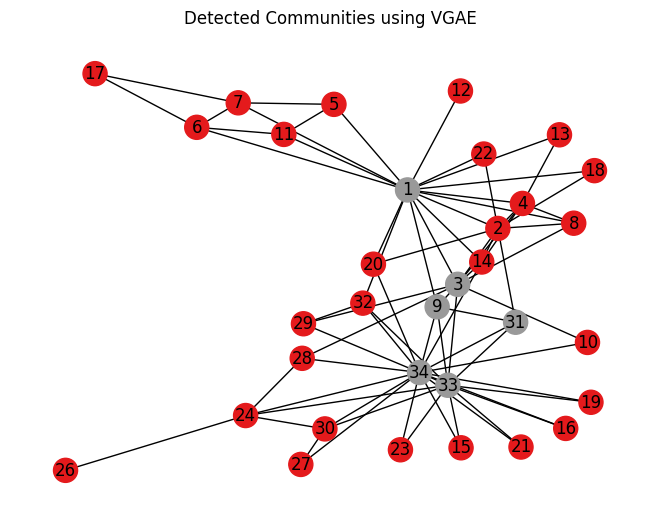

In [18]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    node_color=labels_vgae,
    cmap=plt.cm.Set1,
    with_labels=True
)

plt.title("Detected Communities using VGAE")
plt.show()

In [19]:
import numpy as np

adj = nx.to_numpy_array(G)

import torch.nn as nn

class AutoEncoder(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32,64),
            nn.ReLU(),
            nn.Linear(64,input_dim),
            nn.Sigmoid()
        )

    def forward(self,x):

        z = self.encoder(x)
        recon = self.decoder(z)

        return z,recon

adj_tensor = torch.tensor(adj).float()

model = AutoEncoder(adj.shape[0])

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_fn = nn.MSELoss()

for epoch in range(300):

    z,recon = model(adj_tensor)

    loss = loss_fn(recon, adj_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

embeddings_auto = z.detach().numpy()

print("Autoencoder training complete")

Autoencoder training complete


In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2)

labels_gan = kmeans.fit_predict(embeddings_gan)

labels_vgae = kmeans.fit_predict(embeddings_vgae)

labels_auto = kmeans.fit_predict(embeddings_auto)

In [21]:
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_rand_score

def evaluate(true, pred):

    nmi = normalized_mutual_info_score(true, pred)
    ari = adjusted_rand_score(true, pred)

    return nmi, ari

print("CommunityGAN:", evaluate(ground_truth, labels_gan))

print("VGAE:", evaluate(ground_truth, labels_vgae))

print("Autoencoder:", evaluate(ground_truth, labels_auto))

CommunityGAN: (np.float64(0.14169736421823492), 0.03443619176232275)
VGAE: (np.float64(0.00017498472672268056), -0.018379850238257316)
Autoencoder: (np.float64(0.02739525617643265), -0.002054794520547945)
